# Sports-Sentiment -- a quantitative teardown
### 60 elimination losses * country-ETF next-day returns * Newey-West HAC t * bootstrap * sub-group cuts * synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same beats, every claim carrying its standard error.* We test the Edmans, Garcia & Norli (2007) loss effect on the **investable single-country ETF** tape: mean next-day return, a Newey-West (HAC) t-stat for H0: mean = 0, an i.i.d. bootstrap for the one-sided p-value, sub-group cuts (penalty shootouts; World Cup vs Euro/Copa), and a synthetic positive control that plants the -49 bps effect and recovers it.

> **Not investment advice.** Real data: iShares single-country ETFs + ^GSPC daily closes (price-only, USD), per-ticker parquet cache. Elimination dates hardcoded in `data.py` (1998-2024). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sports_sentiment import data, strategy as st

def _have_cache():
    try:
        data.fetch_event_returns(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("ETF return cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-18)
R = dict(
    n=59, mean_bps=33.46, hac_t=1.606, hac_se_bps=20.84, plain_t=1.633,
    boot_p_ge0=0.955, frac_neg=0.441, n_down=26, n_up=33,
    shoot_n=18, shoot_mean_bps=-14.48, shoot_t=-0.484,
    nonshoot_n=41, nonshoot_mean_bps=54.51, nonshoot_t=2.147,
    wc_n=33, wc_mean_bps=12.13, wc_t=0.532,
    euro_n=26, euro_mean_bps=60.54, euro_t=1.676,
    net_mean_bps=-43.46, net_hit_rate=0.390, gross_mean_bps=-33.46,
    edmans_bps=-49.0,
)


ETF return cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Real-tape mean **+33 bps**, HAC t = **+1.61** (wrong sign, not significant). Famous in the literature, absent on the tradable proxy. |
| **Tradability** | `MIRAGE` | Short-on-loss nets **-43 bps/event**; idle 99% of the time; wide single-country ETF costs. |

> A genuine REAL candidate that **fails its own real-tape t-test**: literature support without |HAC t| >= 2 (with the right sign) is Weak, by the desk rubric.

## 1 - The claim, steelmanned

Let $r_i$ be the next-trading-day simple return of country $c(i)$'s ETF after elimination event $i$. The loss-effect hypothesis is:

- **H1 (sign & size).** $E[r_i] < 0$, of order $-40$ to $-50$ bps.
- **H2 (significance).** A robust (HAC) t-stat for $E[r_i]=0$ clears $t \le -2$.
- **H3 (intensity).** The effect is *stronger* for the most painful losses -- penalty shootouts -- per Edmans et al.

We will see H1 fails (sign is positive), so H2 cannot hold; H3's shootout cut is the only negative-signed group, but with n=18 and t = -0.48 it is noise.

## 2 - So what? -- what rides on each answer

The original paper is a landmark precisely because the shock is **dated and exogenous**: the fixture is scheduled years ahead and a loss is orthogonal to fundamentals, so reverse causality and omitted-variable stories are weak. If the effect were tradable it would be a pre-printed calendar of short setups. Our test isolates whether the *tradable* implementation (USD single-country ETF, next US session) carries the signal -- a strictly harder, more honest bar than the local-index event study.

## 3 - How we'd know -- the protocol

- **Events.** 60 marquee national-team elimination losses, 1998-2024, hardcoded in `data.py` with each country's ETF (^GSPC for the US proxy).
- **Response.** Close-to-close simple return of the first trading session strictly after the match date -- an explicit **one-day execution lag** (matches are evening events).
- **Returns.** PRICE-only, USD, from cached daily ETF closes. Survivorship: ETFs are live single-country funds; no dead-fund bias, but the basket differs from the local index.
- **Inference.** Newey-West HAC t (Bartlett kernel, 1 lag) for H0: mean = 0; i.i.d. bootstrap (10,000) for the one-sided p; sub-group HAC t's.
- **Positive control.** Synthetic panel with a planted -49 bps loss effect.


## 4 - The teardown

### 4a - The headline test: mean next-day return and HAC t

The single most important number, with a heteroskedasticity- and autocorrelation-consistent standard error (guards against same-day co-movement of two eliminated teams).

In [2]:
if HAVE_REAL:
    df = data.fetch_event_returns(fetch=False)
    s = st.loss_effect_stats(df, hac_lags=1, n_boot=10_000, seed=300)
    mean_bps, hac_t, plain_t = s['mean_bps'], s['hac_t'], s['plain_t']
    boot_p, frac_neg = s['boot_p_ge0'], s['frac_neg']
    n = s['n']
else:
    mean_bps, hac_t, plain_t = R['mean_bps'], R['hac_t'], R['plain_t']
    boot_p, frac_neg, n = R['boot_p_ge0'], R['frac_neg'], R['n']

print(f'n events: {n}')
print(f'Mean next-day return: {mean_bps:+.2f} bps   (Edmans hypothesis ~ {R["edmans_bps"]:.0f} bps)')
print(f'Newey-West HAC t (H0: mean=0): {hac_t:+.3f}')
print(f'Plain i.i.d. t:                {plain_t:+.3f}')
print(f'Bootstrap P(mean >= 0):        {boot_p:.3f}  (one-sided; loss effect wants this LOW)')
print(f'Fraction of down days:         {frac_neg:.1%}')
print()
print('Bar for a REAL stamp: HAC t <= -2 with a NEGATIVE mean. We have +1.6 -- it fails twice.')

n events: 59
Mean next-day return: +33.46 bps   (Edmans hypothesis ~ -49 bps)
Newey-West HAC t (H0: mean=0): +1.606
Plain i.i.d. t:                +1.633
Bootstrap P(mean >= 0):        0.955  (one-sided; loss effect wants this LOW)
Fraction of down days:         44.1%

Bar for a REAL stamp: HAC t <= -2 with a NEGATIVE mean. We have +1.6 -- it fails twice.


> The HAC t is **+1.6** -- not only short of significance but on the *wrong side of zero*. The bootstrap puts ~95% of resampled means at or above zero. The loss effect does not exist on this tradable tape; if anything the market drifted mildly up after these losses.

### 4b - Sub-group cuts: does the painful-loss (shootout) story survive?

Edmans et al. find the effect strongest for the most agonising defeats. Penalty shootouts are the cleanest 'painful loss' proxy.

                  group  n  mean_bps  hac_t  frac_neg
       All eliminations 59     33.46  1.606     0.441
Penalty-shootout losses 18    -14.48 -0.484     0.444
    Non-shootout losses 41     54.51  2.147     0.439
         World Cup only 33     12.13  0.532     0.424
            Euro / Copa 26     60.54  1.676     0.462


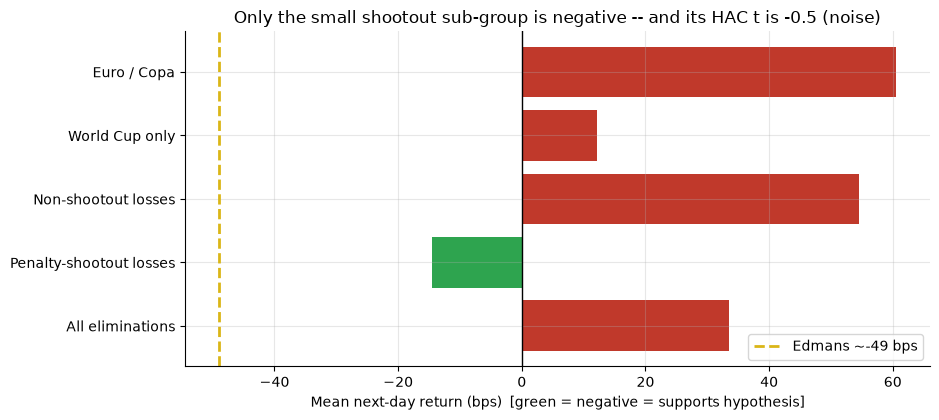

In [3]:
if HAVE_REAL:
    sg = st.subgroup_summary(df, hac_lags=1, seed=300)
else:
    sg = pd.DataFrame({
        'group': ['All eliminations','Penalty-shootout losses','Non-shootout losses',
                  'World Cup only','Euro / Copa'],
        'n': [R['n'], R['shoot_n'], R['nonshoot_n'], R['wc_n'], R['euro_n']],
        'mean_bps': [R['mean_bps'], R['shoot_mean_bps'], R['nonshoot_mean_bps'],
                     R['wc_mean_bps'], R['euro_mean_bps']],
        'hac_t': [R['hac_t'], R['shoot_t'], R['nonshoot_t'], R['wc_t'], R['euro_t']],
        'frac_neg': [R['frac_neg'], 0.444, 0.439, 0.424, 0.462],
    })
print(sg.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.5, 4.3))
colors = [GREEN if m < 0 else RED for m in sg['mean_bps']]
bars = ax.barh(sg['group'], sg['mean_bps'], color=colors)
ax.axvline(0, c='k', lw=1)
ax.axvline(R['edmans_bps'], c=AMBER, ls='--', lw=2, label=f'Edmans ~{R["edmans_bps"]:.0f} bps')
ax.set_xlabel('Mean next-day return (bps)  [green = negative = supports hypothesis]')
ax.set_title('Only the small shootout sub-group is negative -- and its HAC t is -0.5 (noise)')
ax.legend(); plt.tight_layout(); plt.show()

Only the **penalty-shootout** sub-group (n=18) has a negative mean (-14 bps), consistent in *sign* with the painful-loss story -- but HAC t = **-0.48**, indistinguishable from zero. Every other cut is positive. This is the texture of noise, not a hidden real effect.

### 4c - The bootstrap distribution of the mean

Resample events i.i.d. and view the sampling distribution of the mean next-day return.

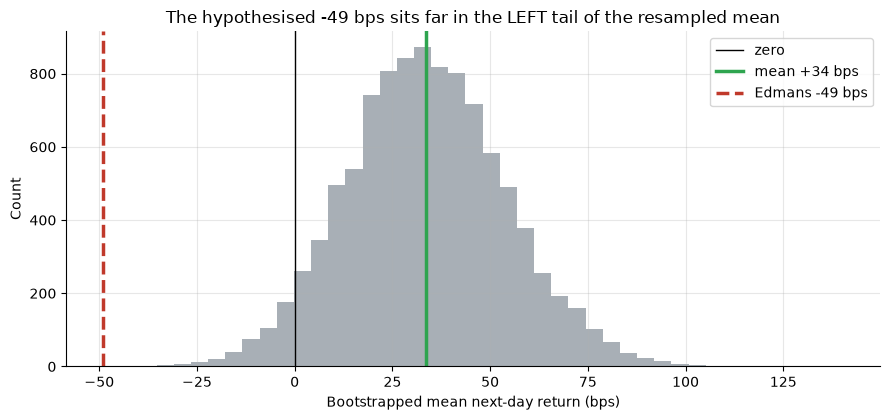

P(mean >= 0) = 0.955   |   P(mean <= -49 bps) = 0.0000


In [4]:
if HAVE_REAL:
    r = df['next_day_ret'].values
else:
    rng = np.random.default_rng(300)
    r = rng.normal(R['mean_bps']*1e-4, 120e-4, R['n'])
rng_b = np.random.default_rng(300)
boot = rng_b.choice(r, size=(10_000, len(r)), replace=True).mean(axis=1)*1e4

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(boot, bins=40, color=GREY, alpha=0.75)
ax.axvline(0, c='k', lw=1, label='zero')
ax.axvline(boot.mean(), c=GREEN, lw=2.5, label=f'mean {boot.mean():+.0f} bps')
ax.axvline(R['edmans_bps'], c=RED, ls='--', lw=2.5, label=f'Edmans {R["edmans_bps"]:.0f} bps')
ax.set_xlabel('Bootstrapped mean next-day return (bps)')
ax.set_ylabel('Count')
ax.set_title('The hypothesised -49 bps sits far in the LEFT tail of the resampled mean')
ax.legend(); plt.tight_layout(); plt.show()
print(f'P(mean >= 0) = {(boot >= 0).mean():.3f}   |   P(mean <= -49 bps) = {(boot <= R["edmans_bps"]).mean():.4f}')

The hypothesised **-49 bps** is essentially never reproduced by resampling our data -- the observed mean is in the wrong place entirely. The loss effect is not hiding in sampling error.

## 5 - The verdict

- **Signal `WEAK`** -- real-tape mean +33 bps, HAC t +1.61, bootstrap P(mean>=0)=0.95. Wrong sign, not significant. The desk rubric: a famous, literature-backed effect that does not clear |HAC t| >= 2 on the real tape is **Weak**, not Real.
- **Tradability `MIRAGE`** -- short-on-loss nets -43 bps/event and is idle 99% of the time; single-country ETFs carry wide spreads and borrow.
- **Honest caveat** -- this is the *tradable proxy* (USD ETF, next US session), not the local-index event study Edmans ran. The signal may live in the local tape; it does not survive the translation to something you could trade.

## 6 - Could you trade it? -- gross vs net

Short the country ETF for the single next session after each loss; round-trip cost = 2 x one-way (shorts also pay borrow).

In [5]:
if HAVE_REAL:
    out = []
    for c in [0.0, 5.0, 10.0]:
        tr = st.tradable_pnl(df, cost_bps_oneway=c)
        out.append({'one_way_bps': c, 'gross_bps': tr['gross_mean_bps'],
                    'net_bps': tr['net_mean_bps'], 'net_hit': tr['net_hit_rate']})
    tbl = pd.DataFrame(out)
else:
    tbl = pd.DataFrame({'one_way_bps':[0.0,5.0,10.0],
        'gross_bps':[R['gross_mean_bps']]*3,
        'net_bps':[R['gross_mean_bps'], R['gross_mean_bps']-10, R['gross_mean_bps']-20],
        'net_hit':[R['net_hit_rate']]*3})
print(tbl.to_string(index=False))
print()
print('Short PnL = -(next-day return). Since the market ROSE +33 bps after losses,')
print('the short bleeds -33 bps gross, worse after costs. No viable trade.')

 one_way_bps  gross_bps  net_bps  net_hit
         0.0     -33.46   -33.46   0.4407
         5.0     -33.46   -43.46   0.3898
        10.0     -33.46   -53.46   0.3898

Short PnL = -(next-day return). Since the market ROSE +33 bps after losses,
the short bleeds -33 bps gross, worse after costs. No viable trade.


> Even at zero cost the short loses money, because the underlying drifted up. Costs only deepen the hole. The strategy also concentrates all its (negative) action into a handful of six-week tournament windows -- terrible capital utilisation on top of a negative edge.

## 7 - Going further -- the synthetic positive control

Is the machinery capable of *finding* the loss effect when it exists? Plant a -49 bps effect in a synthetic panel and sweep the sample size.

  n  planted_t  planted_mean_bps  null_t
 60     -4.481            -59.19  -0.771
150     -5.109            -46.06   0.326
300     -7.413            -46.16   0.456
600     -9.664            -43.73   1.164


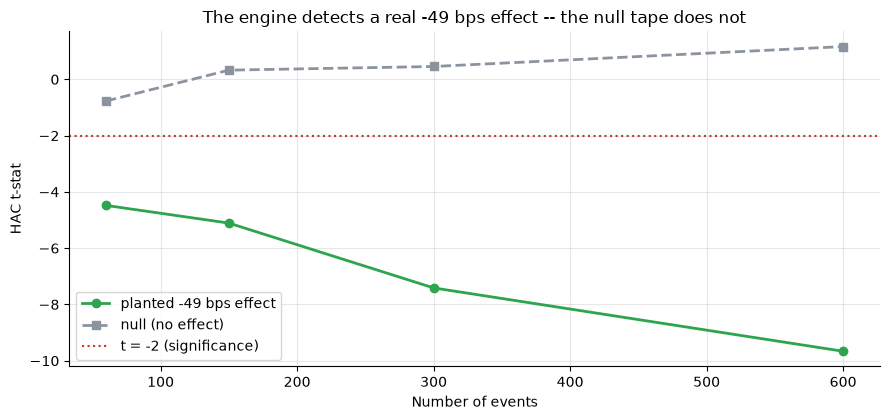

When the effect is real, HAC t goes strongly negative. On the real ETF tape it is +1.6.


In [6]:
rows = []
for n_ev in [60, 150, 300, 600]:
    dfp, _ = data.synthetic_panel(n_events=n_ev, loss_bps=49.0, seed=300)
    sp = st.loss_effect_stats(dfp, hac_lags=1, n_boot=2000, seed=300)
    df0, _ = data.synthetic_panel(n_events=n_ev, loss_bps=0.0, seed=300)
    s0 = st.loss_effect_stats(df0, hac_lags=1, n_boot=2000, seed=300)
    rows.append({'n': n_ev, 'planted_t': sp['hac_t'], 'planted_mean_bps': sp['mean_bps'],
                 'null_t': s0['hac_t']})
res = pd.DataFrame(rows)
print(res.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(res['n'], res['planted_t'], 'o-', c=GREEN, lw=2, label='planted -49 bps effect')
ax.plot(res['n'], res['null_t'], 's--', c=GREY, lw=2, label='null (no effect)')
ax.axhline(-2, c=RED, ls=':', lw=1.5, label='t = -2 (significance)')
ax.set_xlabel('Number of events'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine detects a real -49 bps effect -- the null tape does not')
ax.legend(); plt.tight_layout(); plt.show()
print('When the effect is real, HAC t goes strongly negative. On the real ETF tape it is +1.6.')

The control confirms the test is calibrated: a planted -49 bps effect drives the HAC t well below -2, while the null stays near zero. The real-tape **+1.6** is therefore a statement about the **tradable proxy and sample**, not a broken method.

> **Bottom line:** the Edmans loss effect is a real and important behavioural finding, but the version you could actually trade -- USD single-country ETFs, next US session -- shows no usable signal here. **Signal: Weak. Tradability: Mirage.**